# 深度学习

## 神经网络
* 输入层->隐藏层->输出层
* 公式：$y = h(b+w_1x_2+w_2x_2)$,$h$为激活函数，$w_1,w_2$为权重，$x_1,x_2$为输入层
* 终极目标：使损失函数降到最小
```
深度学习训练流程：
选出训练集跟测试集，
用训练集训练（初始化各个权重跟偏置(参数)->计算损失函数关于各个权重参数的梯度->用学习率来沿梯度方向更新参数）->最终使loss变得最小，
测试集测试
```

### 激活函数
* 在输出层，掌握着输出的结果。

#### 阶跃函数和sigmoid函数的实现与比较
* 阶跃函数：输入的数值超过0，输出的结果就是1；否则就输出0
* sigmoid函数的公式为：$h(x) = \frac{1}{1+exp(-x)}$ (二元分类)
* 共同点：都是非线性函数，并且神经网络的激活函数必须要用非线性函数，如果用线性函数那么增加神经网络的层数就没有意义。

D:\Code\Conda\py312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


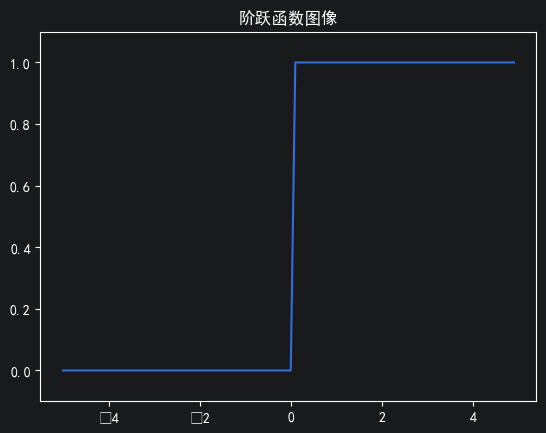

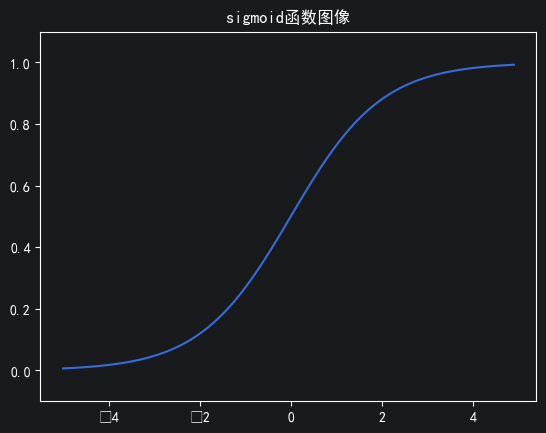

In [1]:
from copyreg import pickle

import matplotlib.pyplot as plt
import numpy as np


# 创建阶跃函数方法
def step_function(x):
    return np.array(x > 0, dtype=np.int8)


# 创建sigmoid函数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


x = np.arange(-5.0, 5.0, 0.1)  # 生成从-5.0到5.0的均匀数组，间隔0.1

# 阶跃函数
y = step_function(x)

# sigmoid函数
y_m = sigmoid(x)
# 画图
plt.plot(x, y)
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.title('阶跃函数图像')
plt.ylim(-0.1, 1.1)  # y轴范围
plt.show()

plt.plot(x, y_m)
plt.title('sigmoid函数图像')
plt.ylim(-0.1, 1.1)  # y轴范围
plt.show()


#### ReLU函数
* 当输入值大于0时，直接输出该值；否则输出0

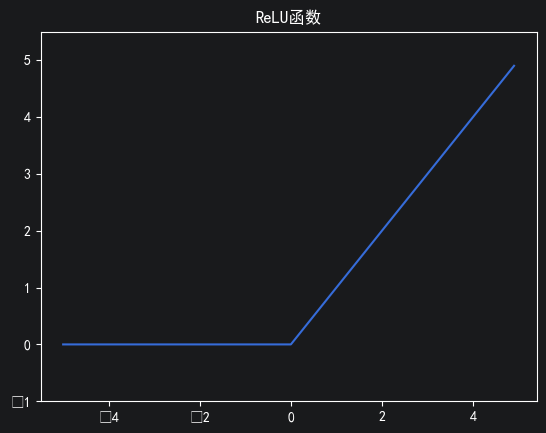

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def relu(x):
    return np.maximum(0, x)  # 选择最大值输出


x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.title("ReLU函数")
plt.plot(x, y)
plt.ylim(-1.0, 5.5)
plt.show()


#### softmax函数（多元分类，归一化）
* 输入数值的指数函数值除以输入数值的指数函数的和
* 单调递增

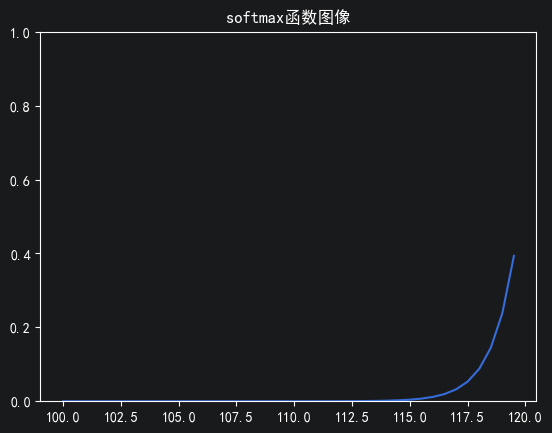

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def softmax(x):
    c = np.max(x)
    exp_x = np.exp(x - c)
    sum_exp_x = np.sum(exp_x)
    y = exp_x / sum_exp_x
    return y


x = np.arange(100, 120, 0.5)
y = softmax(x)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.title("softmax函数图像")
plt.plot(x, y)
plt.ylim(0, 1)
plt.show()

#### 手写数字识别（前向传播）

In [4]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
from Missive_Japan_One_Two.classcd.dataset.mnist import load_mnist
import pickle


# 提取测试数据集
def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=True,one_hot_label=False)  # normaliz:归一化，flatten:展平成一维数组
    return x_test, t_test, x_train


# 创建保存权重参数的方法
def init_network():
    with open('sample_weight.pkl', 'rb') as f:
        network = pickle.load(f)
    return network


# 前向传播
def predict(network1, x):
    W1, W2, W3 = network1['W1'], network1['W2'], network1['W3']
    b1, b2, b3 = network1['b1'], network1['b2'], network1['b3']
    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    z3 = sigmoid(a3)
    return z3


x, t, train = get_data()
network1 = init_network()

accuracy_cnt = 0
batch_size = 100  # 批数量
# 一百个一百个的训练
for i in range(0, len(x), batch_size):
    x_batch = x[i:i + batch_size]
    y_batch = predict(network1, x_batch)
    p = np.argmax(y_batch, axis=1)  # 获取概率最高元素索引
    accuracy_cnt += np.sum(p == t[i:i + batch_size])  # 预测结果与真实结果比较得出布尔值的和在相加

print('Accuracy:' + str(float(accuracy_cnt) / len(x)))
print(x.shape)
print(train.shape)

Accuracy:0.9352
(10000, 784)
(60000, 784)


C:\Users\23999\AppData\Local\Temp\ipykernel_47420\3214481474.py:17: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  network = pickle.load(f)


### 损失函数(loss gunctioon)

#### 均方误差(mean squared errorr)
* 均方误差公式：$E = \frac{1}{2} \sum_k(y_k-t_k)^2$,其中$y_k$表示神经网络输出，$t_k$表示监督数据，$k$表示数据的维数。其实就是计算输出数据与测试数据个元素之差的平方之和 再除以2

In [5]:
def mean_squared_error(y, t):
    return 0.5 * np.sum((y - t) ** 2)

#### 交叉熵误差(cross entropy error)
* 公式：$E = -\sum_k t_k*logy_k$
*

In [6]:

def coross_entroopy_error(y, t):
    delta = 1e-7  # 保护log过大无法计算
    return -np.sum(t * np.log(y + delta))


#### 使用交叉熵误差学习小批量数据(mini-batch)

In [7]:
import sys, os

sys.path.append(os.pardir)
import numpy as np
from Missive_Japan_One_Two.classcd.dataset.mnist import load_mnist
import pickle

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True,
                                                  one_hot_label=True)  # normaliz:归一化，one_hot_label:标签 正确为1 其余为0

train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size)  # 从train_size中随机选择十行
x_batch = x_train[batch_mask]  # 根据batch_mask的十个随机索引选出十行
t_batch = t_train[batch_mask]


# 制作交叉熵误差函数
def coross_entroopy_error(y, t):
    # 如果传入的y（输出）是一维，那么需要展开改变数据的形状
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(t * np.log(y + 1e-7)) / batch_size


# 需要先通过神经网络前向传播得到预测结果
# 加载预训练权重
def init_network():
    with open('sample_weight.pkl', 'rb') as f:
        network = pickle.load(f)
    return network


# 前向传播函数
def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']
    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)  # 输出层使用softmax
    return y


# 获取网络并进行预测
network = init_network()
y_batch = predict(network, x_batch)
# 计算交叉熵误差（使用预测结果和真实标签）
loss = coross_entroopy_error(y_batch, t_batch)
print(loss)

4.2266305685043335


C:\Users\23999\AppData\Local\Temp\ipykernel_47420\1186007488.py:33: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  network = pickle.load(f)


### 导数跟梯度

#### 导数与数值微分
* 导数就是某一瞬间的变化率，公式：$\frac {df(x)}{dx} = lim_{h->0} \frac {f(x+h) - f(x)} {h}$
* 偏导：方程式有两个变量，确定一个变量的值，求另一个变量的导数叫做偏导

In [8]:


# 创建求导数方法（数值差分）
def numerical_diff(f, x):
    h = 1e-4  # 0.001
    return (f(x + h) - f(x - h)) / (2 * h)


# 创建公式方法 x_0 ** 2 + x_1 ** 2 = f(x,x)
def funtion(x):
    return x[0] ** 2 + x[1] ** 2


# 当x_1等于4时，求x_0=3时的偏导
def funtion_0(x):
    return x ** 2 + 4 ** 2


numerical_diff(funtion_0, 3)


# 当x_0等于6时，求x_1=8时的偏导
def funtion_1(x):
    return 6 ** 2 + x ** 2


numerical_diff(funtion_1, 8)

15.999999999891656

#### 梯度下降
* 梯度就是导数的向量场，

C:\Users\23999\AppData\Local\Temp\ipykernel_47420\416998258.py:67: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.draw()


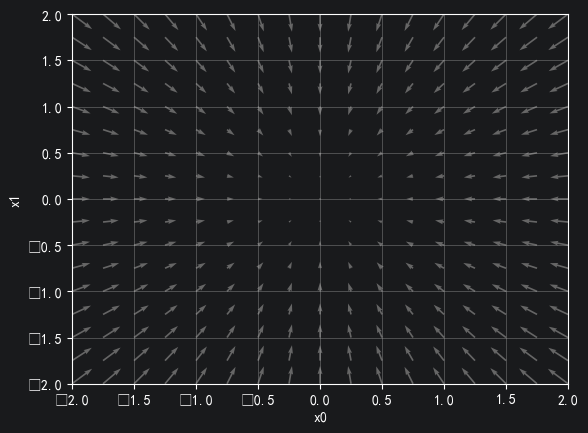

In [9]:
import numpy as np
import matplotlib.pylab as plt


# 求导
def _numerical_gradient_no_batch(f, x):
    h = 1e-4  # 0.0001
    grad = np.zeros_like(x)  # 生成一个跟x形状相同的全0数组

    for idx in range(x.size):
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x)  # f(x+h)

        x[idx] = tmp_val - h
        fxh2 = f(x)  # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2 * h)

        x[idx] = tmp_val

    return grad


def numerical_gradient(f, X):
    if X.ndim == 1:
        return _numerical_gradient_no_batch(f, X)
    else:
        grad = np.zeros_like(X)

        for idx, x in enumerate(X):
            grad[idx] = _numerical_gradient_no_batch(f, x)

        return grad


def function_2(x):
    if x.ndim == 1:
        return np.sum(x ** 2)
    else:
        return np.sum(x ** 2, axis=1)


def tangent_line(f, x):
    d = numerical_gradient(f, x)
    print(d)
    y = f(x) - d * x
    return lambda t: d * t + y


if __name__ == '__main__':
    x0 = np.arange(-2, 2.5, 0.25)
    x1 = np.arange(-2, 2.5, 0.25)
    X, Y = np.meshgrid(x0, x1)

    X = X.flatten()
    Y = Y.flatten()

    grad = numerical_gradient(function_2, np.array([X, Y]).T).T

    plt.figure()
    plt.quiver(X, Y, -grad[0], -grad[1], angles="xy", color="#666666")
    plt.xlim([-2, 2])
    plt.ylim([-2, 2])
    plt.xlabel('x0')
    plt.ylabel('x1')
    plt.grid()
    plt.draw()
    plt.show()


#### 完整的实现手写数字识别的神经网络

##### 创建类

In [10]:
import sys, os

sys.path.append(os.pardir)
from classcd.common.functions import *
from classcd.common.gradient import numerical_gradient


class TwoLayerNet:
    # 做权重跟偏置
    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        #
        self.params = {}
        # 第一层权重
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        # 第一层偏置
        self.params['b1'] = np.zeros(hidden_size)
        # 第二层权重 全0数组
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        # 第二层偏置 全0数组
        self.params['b2'] = np.zeros(output_size)

    # 识别推理方法
    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']

        b1, b2 = self.params['b1'], self.params['b2']

        # 公式
        a1 = np.dot(x, W1) + b1
        # 激活函数
        z1 = sigmoid(a1)

        a2 = np.dot(z1, W2) + b2

        y = softmax(a2)

        return y

    # 计算损失函数
    def loss(self, x, t):
        # 返回的是预测结果
        y = self.predict(x)

        # 对比预测结果跟实际结果 计算损失
        return cross_entropy_error(y, t)

    # 计算识别精度方法
    def accuracy(self, x, t):
        y = self.predict(x)
        # 获取最大的概率值的索引
        y = np.argmax(y, axis=1)

        t = np.argmax(t, axis=1)

        # 对比俩索引是否相同，相同为true 不相同为false，计算和，除以总样本计算精度
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    #  计算权重参数 梯度
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}

        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

        return grads

    # 加速版梯度，混合前向传播和反向传播
    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}

        batch_num = x.shape[0]

        # forward 前向传播
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        # backward  反向传播
        dy = (y - t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)

        dz1 = np.dot(dy, W2.T)
        da1 = sigmoid_grad(a1) * dz1
        grads['W1'] = np.dot(x.T, da1)
        grads['b1'] = np.sum(da1, axis=0)

        return grads


##### mini-batch实现

train acc, test acc | 0.09871666666666666, 0.098 num:1
train acc, test acc | 0.8763, 0.8793 num:2
train acc, test acc | 0.9052833333333333, 0.9108 num:3
train acc, test acc | 0.9185833333333333, 0.9186 num:4
train acc, test acc | 0.9248166666666666, 0.9273 num:5
train acc, test acc | 0.93265, 0.9327 num:6
train acc, test acc | 0.9375333333333333, 0.9374 num:7
train acc, test acc | 0.94185, 0.942 num:8
train acc, test acc | 0.9454333333333333, 0.9443 num:9
train acc, test acc | 0.9491333333333334, 0.948 num:10
train acc, test acc | 0.9521166666666666, 0.9514 num:11
train acc, test acc | 0.9548166666666666, 0.9517 num:12
train acc, test acc | 0.9574333333333334, 0.9554 num:13
train acc, test acc | 0.96005, 0.9569 num:14
train acc, test acc | 0.96145, 0.9587 num:15
train acc, test acc | 0.9636666666666667, 0.9611 num:16
train acc, test acc | 0.9650333333333333, 0.9619 num:17


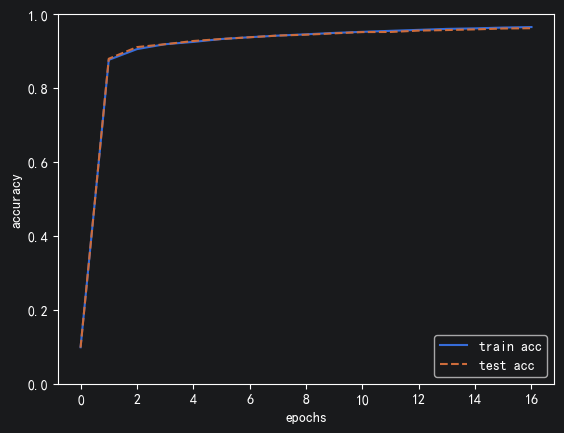

In [11]:
import sys, os

sys.path.append(os.pardir)
import numpy as np
import matplotlib.pyplot as plt
from classcd.dataset.mnist import load_mnist

# from two_layer_net import TwoLayerNet


(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.2

train_loss_list = []
train_acc_list = []
test_acc_list = []
# 600
iter_per_epoch = max(train_size / batch_size, 1)
num = 0
for i in range(iters_num):
    # 随机选100个train_size中的索引
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # grad = network.numerical_gradient(x_batch, t_batch)

    grad = network.gradient(x_batch, t_batch)

    # 更新权重跟偏置
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 计算损失
    loss = network.loss(x_batch, t_batch)
    # 更新loss
    train_loss_list.append(loss)

    # 每次更新600个数值，更新17轮
    if i % iter_per_epoch == 0:
        num += 1
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc), 'num:' + str(num))

#
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

#### 反向传播
* 利用输出层的损失函数loss的值向前计算每个神经元的误差梯度，
* 再用误差梯度来计算各个权重跟偏置对于loss的梯度，
* 利用梯度下降来更新权重跟偏置，
* 在计算损失函数
* 循环往复，找到最合适的权重跟偏置，使损失函数降到最小，

（1）前向传播（Forward Propagation）
前向传播是神经网络通过层级结构和参数，将输入数据逐步转换为预测结果的过程，实现输入与输出之间的复杂映射。
前向传播
输入层:
        输入层接收训练集中的样本数据。
        每个样本数据包含多个特征，这些特征被传递给输入层的神经元。
        通常，还会添加一个偏置单元来辅助计算。
隐藏层：
        隐藏层的每个神经元接收来自输入层神经元的信号。
        这些信号与对应的权重相乘后求和，并加上偏置。
        然后，通过激活函数（如sigmoid）处理这个求和结果，得到隐藏层的输出。
输出层：
        输出层从隐藏层接收信号，并进行类似的加权求和与偏置操作。
        根据问题的类型，输出层可以直接输出这些值（回归问题），
        或者通过激活函数（如softmax）转换为概率分布（分类问题）。
----
（2）反向传播（Back Propagation）
反向传播算法利用链式法则，通过从输出层向输入层逐层计算误差梯度，高效求解神经网络参数的偏导数，
以实现网络参数的优化和损失函数的最小化。

反向传播
利用链式法则：
        反向传播算法基于微积分中的链式法则，通过逐层计算梯度来求解神经网络中参数的偏导数。
从输出层向输入层传播：
        算法从输出层开始，根据损失函数计算输出层的误差，然后将误差信息反向传播到隐藏层，逐层计算每个神经元的误差梯度。
计算权重和偏置的梯度：
        利用计算得到的误差梯度，可以进一步计算每个权重和偏置参数对于损失函数的梯度。
参数更新：
        根据计算得到的梯度信息，使用梯度下降或其他优化算法来更新网络中的权重和偏置参数，以最小化损失函数。
2、反向传播的原理
（1）链式法则（Chain Rule）
链式法则是微积分中的一个基本定理，用于计算复合函数的导数。
如果一个函数是由多个函数复合而成，那么该复合函数的导数可以通过各个简单函数导数的乘积来计算。

链式法则
简化梯度计算：
        在神经网络中，损失函数通常是一个复合函数，由多个层的输出和激活函数组合而成。
        链式法则允许我们将这个复杂的复合函数的梯度计算分解为一系列简单的局部梯度计算，从而简化了梯度计算的过程。
高效梯度计算：
        通过链式法则，我们可以从输出层开始，逐层向前计算每个参数的梯度，
        这种逐层计算的方式避免了重复计算，提高了梯度计算的效率。
支持多层网络结构：
        链式法则不仅适用于简单的两层神经网络，还可以扩展到具有任意多层结构的深度神经网络。
        这使得我们能够训练和优化更加复杂的模型。
（2）偏导数
偏导数是多元函数中对单一变量求导的结果，它在神经网络反向传播中用于量化损失函数随参数变化的敏感度，从而指导参数优化。

### 参数的更新
* SGD(随机梯度下降法)
  缺点：梯度的下降方向并没有直接指向最小值的方向，所以表现的低效
* Momentum(动量)
  在SGD基础上增加一个变量$v$，让变量$v$减去梯度，然后跟权重等参数相加，对应物理的速度，像小球一样在碗里滚动，但是受相互力的影响，y轴还是不稳定
* AdaGrad(自适应学习率)
  在SGD基础上加了新变量$h$,$h$保存了以前的所有梯度值的平方和，所以在更新参数时通过 梯度 乘上 $\frac {1}{\sqrt h}$,来逐渐减小学习率，前期变化越大的，后期变化越小。
* Adam(Momentum+AdaGrad)

### 权重的初始化
* 不能将权重初始值设置成一样的值，因为在反向传播中会进行相同的更新，所以就会生成对称值，也就失去了利用神经网络拥有不用的权重的意义，所以必须随机生成出初始值。_
* 所以我们可以通过激活函数反推权重的随机生成方式
* * 根据使用的tanh和sigmoid等S型曲线激活函数，可以利用前一层的节点数$n$,使用标准差为$ \frac{1}{\sqrt n}$的高斯分布来初始化权重
* * * 伪代码：
` py
node_num = 100 # 前一层的节点数
 w = \ np.random.radn(node_num,node_num) / np.sqrt(node_num)
`

* * 根据ReLU的激活函数，可以利用前一层的节点数$n$,使用标准差为$ \sqrt \frac{2}{n}$的高斯分布来初始化权重，称作He初始值
* * * 伪代码：
` py
node_num = 100 # 前一层的节点数
 w = \ np.random.radn(node_num,node_num) / np.sqrt(2.0 / node_num)`

### 正则化

* 过拟合是指只能拟合训练数据，不能很好拟合训练外的数据。泛化能力较低
* 发生过拟合的两个主要原因：
* * 模型拥有大量参数，表现力强
* * 训练数据太少


#### 权重衰减
* 就是对大的权重进行惩罚，来抑制过拟合，
* 引入一个参数，来控制权重衰减的程度，让损失函数加上权重的$L_2$范数来抑制过拟合

#### Dropout
* 在学习过程中随机删除神经元来抑制过拟合。

## CNN 卷积神经网络
*  CNN主要用于图像处理、音频识别等场景
* 上边介绍的神经网络结构是：
输入->Affine(全连接层，相邻的所有神经元都有连接)->激活函数
->Affine(全连接层，相邻的所有神经元都有连接)->激活函数
->Affine(全连接层，相邻的所有神经元都有连接)->激活函数...
->输出概率

* CNN卷积神经网络结构是：
输入->卷积层(Convoolution)->激活函数->池化层(Pooling)
->卷积层(Convoolution)->激活函数->池化层(Pooling)
->卷积层(Convoolution)->激活函数->池化层(Pooling)...
->输出概率

### 卷积层(Convoolution)
* 卷积层可以让输入矩阵的形状保持不变。
* 一般卷积层有个滤波器，是固定数据的矩阵。
* 滤波器的各个元素与输入矩阵的对应位置的数据进行相乘再求和 有偏置再加偏置 组成输出矩阵。
* 滑动滤波器在输入矩阵的位置叫做步幅。

### 池化层(Poooling)
* 池化层是缩小空间大小
* Max池化：在输入矩阵中选出目标区域的最大值，组成新的矩阵
m

# NLP 自然语言处理

## 基于基数的方式来进行语言预测()
*  使用语料库对单词进行*向量化*（根据单词含义以及周围单词的分布构成），对各个单词出现的频率进行*汇总统计形成共现矩阵*，然后根据*余弦相似度*对相似的单词进行*降序排序*。
* 改进：如果一些常用词出现的次数比较大，那么使用上边的办法就会不准确。
* * 可以将共现矩阵变成*点互信息*(PMI,运用二者出现的概率来判断),再将PMI矩阵进行*SVD奇异值分解得到降维矩阵*(在保留重要信息的同时减少矩阵的维度,有大的稀疏向量转向小的密集向量)，在该向量空间中，含义相同的单词理应距离更近。
* 词汇量太大需要消耗大量的计算资源和时间

## word2vec(自然语言向量化)
* 基于推理的方式来进行语言预测
* 输入上下文，输出中间词，即目标词
* 一般有两种模型：CBOW模型、skip-gram模型

## CBOW模型
* CBOW模型的流程(例如输入I跟You，得出Love)：
* * 输入层->将数字I,You转化成one-hot向量(每个单词对应的位置为1，其余为全0)
* * ->中间层(将两个向量分别与输入层的初始化权重相乘，然后得出的两个结果相加求平均成0.5,输出每个单词的得分。)
* * ->输出层(利用激活函数Softmax函数得到各个单词的概率值，选出最高的概率输出 Love)。

* CBOW模型的流程的优化(例如输入I跟You，得出Love)：
* * 如果数据太多，之前的做法运算量太大，太消耗时间
* * 输入层->将数字I,You转化成one-hot向量(每个单词对应的位置为1，其余为全0)
* * ->中间层,新增Embedding词嵌入层(将两个向量分别与输入层的初始化权重对应单词ID的行相乘，然后得出的两个结果相加求平均成0.5,输出每个单词的得分。)
* * ->输出层(增加负采样(将多分类变为二分类),利用激活函数Softmax函数得到各个单词的概率值,对于正确的单词标签得到交叉熵损失函数,然后反向传播调整权重,循环往复,使得合适的权重得到最小的损失,锁后选出最高的概率输出 Love)。

## 向量化的作用以及重要性：
* 它可以把某一领域学到的知识应用于其他领域。迁移学习
* 流程:输入自然语言->将自然语言向量化->机器学习系统->输出结果

## RNN(循环神经网络)
* RNN存在环路，通过数据的循环，从过去集成的数据传递到现在和未来，内部具有记忆隐藏状态的能力

<img alt="RNN 正向传播时序图加计算图" height="500" src="images/RNN 正向传播时序图加计算图.png" title="RNN 正向传播时序图加计算图" width="500"/>

### 普通RNN的缺点
* 当长期记忆时，会出现梯度爆炸（策略：梯度裁剪）和梯度消失

#### 梯度消失的应对策略，加LSTM层

* 新增了记忆单元$c_t$，存储了从过去到时刻$t$的所有必要信息，但是不参与输出
* 新增“门”的概念，分为输入门、遗忘门、输出门。
* * 门有专门的权重来控制门的开关以及开合的大小，使用sigmoid函数输出0-1的实数来控制

## Seq2Seq(Encoder->Decoder 编码器->解码器 )
* 当前的的编码器对输入语句进行编码，将语句向量化等操作**变成固定长度的向量**传递给解码器
* 解码器进行一系列操作输出目标语句

### 当前的seq2seq的缺点主要是：不管多长的语句 ，编码器都会把它转化为固定长度的向量，不够灵活。

## Attrion结构(注意力机制)

* 编码器的改进：之前seq2seq的编码器输出的是最后一个状态的向量，现在改为输出各个单词的隐藏状态的向量，形成向量矩阵传输给解码器。
* 解码器的改进：
* * (Weight Sum层)我们要找出输入的单词的对应向量所代表的值，就得从矩阵中选，但是从矩阵中选出若干个这操作无法微分，所以无法进行反向传播。
* * * 所以我们就全选然后乘以每个单词重要程度的权重，最后计算表示各个单词重要度的权重的单词向量的加权和，从而得到目标向量。
* * (Attention Weight层) 如何获得各个单词的重要程度的权重： 用输出矩阵每一行向量分别跟解码器的LSTM层的隐藏状态向量进行相似度的计算（可以用内积，可以用余弦函数等）,得到得分，然后用Softmax进行归一化，变成和为1的概率值。